# L3 Cavity with Conical Holes — Fabrication Taper Study
During dry etching (RIE/ICP), hole sidewalls can develop a slight taper,
producing cone-shaped holes — wider at the top (etch entry) and narrower at
the bottom. This notebook models the effect on the L3 cavity Q-factor using
a staircase approximation (multiple thin slab sub-layers with varying radii).

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import legume
from legume import Circle

## Band structure of the perfect PhC (unit cell)

Bandgap: 0.2489 – 0.3274,  centre f_target = 0.2882


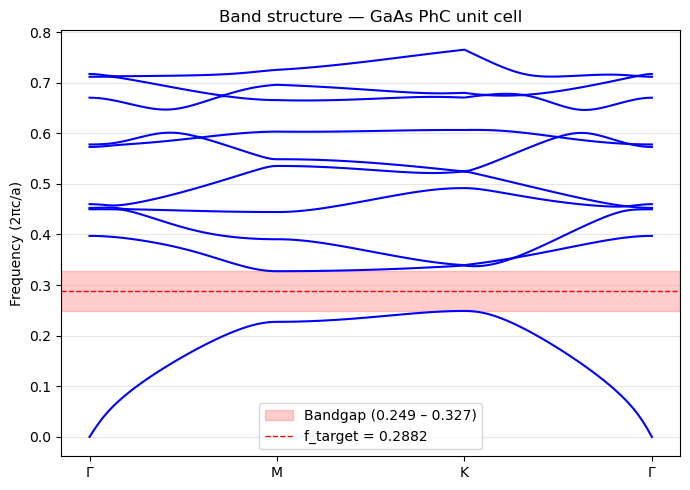

In [13]:
# ── Physical parameters ─────────────────────────────────────────────────────
a_nm = 250              # lattice constant in nm
ra = 75 / a_nm          # hole radius in units of a
dslab = 170 / a_nm      # slab thickness in units of a
n_slab = 3.46           # refractive index (GaAs)

lattice_unit = legume.Lattice('hexagonal')
phc_unit = legume.PhotCryst(lattice_unit)
phc_unit.add_layer(d=dslab, eps_b=n_slab**2)
phc_unit.add_shape(Circle(x_cent=0, y_cent=0, r=ra))

path_dict = lattice_unit.bz_path(['G', 'M', 'K', 'G'], [40, 40, 40])
kpoints = path_dict['kpoints']

gme_bands = legume.GuidedModeExp(phc_unit, gmax=3.0, truncate_g='tbt')
gme_bands.run(kpoints=kpoints, gmode_inds=[0], verbose=False, numeig=10)

# Find the largest complete bandgap
freqs_b = gme_bands.freqs
f_lb, f_ub, f_target = None, None, None
best_gap = 0
for i in range(freqs_b.shape[1] - 1):
    top = np.max(freqs_b[:, i])
    bot = np.min(freqs_b[:, i + 1])
    if bot > top and (bot - top) > best_gap:
        best_gap = bot - top
        f_lb, f_ub = top, bot
        f_target = (top + bot) / 2

print(f'Bandgap: {f_lb:.4f} \u2013 {f_ub:.4f},  centre f_target = {f_target:.4f}')

# Plot band structure
fig, ax = plt.subplots(figsize=(7, 5))
for i in range(freqs_b.shape[1]):
    ax.plot(freqs_b[:, i], 'b-', lw=1.5)
ax.axhspan(f_lb, f_ub, alpha=0.2, color='red',
           label=f'Bandgap ({f_lb:.3f} \u2013 {f_ub:.3f})')
ax.axhline(f_target, color='red', ls='--', lw=1,
           label=f'f_target = {f_target:.4f}')
ax.set_xticks([0, 40, 80, 120])
ax.set_xticklabels(['\u0393', 'M', 'K', '\u0393'])
ax.set_ylabel('Frequency (2\u03c0c/a)')
ax.set_title('Band structure \u2014 GaAs PhC unit cell')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
# ── Supercell parameters ───────────────────────────────────────────────────
Nx, Ny = 16, 10

# Initialize supercell lattice
lattice = legume.Lattice([Nx, 0], [0, Ny*np.sqrt(3)/2])

# Build hole positions in one quadrant (L3: skip ix=0,1 at iy=0)
xp, yp = [], []
nx, ny = Nx//2 + 1, Ny//2 + 1
for iy in range(ny):
    for ix in range(nx):
        if iy == 0 and ix in (0, 1):
            continue
        xp.append(ix + (iy%2)*0.5)
        yp.append(iy*np.sqrt(3)/2)

nc = len(xp)

# Optimized end-hole shift (from autograd optimization notebook)
dx_opt = 0.17964
dx = np.zeros(nc)
dy = np.zeros(nc)
dx[0] = dx_opt  # ic=0 -> end holes at (+-2, 0)

print(f'nc = {nc} holes per quadrant')
print(f'Optimized end-hole shift: dx[0] = {dx_opt}a = {dx_opt * a_nm:.1f} nm')

nc = 52 holes per quadrant
Optimized end-hole shift: dx[0] = 0.17964a = 44.9 nm


In [15]:
import os
from datetime import datetime

SAVE_DATA = True

def save_sweep(name, arrays_dict, **extra_params):
    """Save sweep results to a timestamped folder in data/.

    Parameters
    ----------
    name : str
        Short sweep name (used in folder name).
    arrays_dict : dict
        {label: np.array} — each array is saved as a .npy file.
    **extra_params :
        Sweep-specific parameters to log in info.txt.
    """
    if not SAVE_DATA:
        return
    timestamp = datetime.now().strftime('%Y-%m-%d_%H%M%S')
    folder = os.path.join('data', f'{timestamp}_{name}')
    os.makedirs(folder, exist_ok=True)

    # Save arrays
    for label, arr in arrays_dict.items():
        np.save(os.path.join(folder, f'{label}.npy'), np.asarray(arr))

    # Write info.txt
    with open(os.path.join(folder, 'info.txt'), 'w') as f:
        f.write(f'Sweep: {name}\n')
        f.write(f'Date: {timestamp}\n\n')

        f.write('--- Physical parameters ---\n')
        f.write(f'a_nm = {a_nm}\n')
        f.write(f'ra = {ra:.4f} ({ra * a_nm:.1f} nm)\n')
        f.write(f'dslab = {dslab:.4f} ({dslab * a_nm:.1f} nm)\n')
        f.write(f'n_slab = {n_slab}\n\n')

        f.write('--- Supercell ---\n')
        f.write(f'Nx = {Nx}, Ny = {Ny}\n')
        f.write(f'nc = {nc}\n')
        f.write(f'dx_opt = {dx_opt} ({dx_opt * a_nm:.1f} nm)\n\n')

        f.write('--- GME settings ---\n')
        f.write(f'gmax = {gmax}\n')
        f.write(f'truncate_g = {truncate_g}\n')
        f.write(f'numeig = 10\n')
        f.write(f'gmode_inds = [0]\n\n')

        f.write('--- Bandgap ---\n')
        f.write(f'f_lb = {f_lb:.6f}\n')
        f.write(f'f_ub = {f_ub:.6f}\n')
        f.write(f'f_target = {f_target:.6f}\n')
        f.write(f'f_base = {f_base:.6f}\n')
        f.write(f'Q_base = {Q_base:.1f}\n\n')

        f.write('--- Sweep-specific parameters ---\n')
        for k, v in extra_params.items():
            f.write(f'{k} = {v}\n')

        f.write(f'\n--- Saved arrays ---\n')
        for label in arrays_dict:
            f.write(f'{label}.npy\n')

    print(f'Results saved to {folder}/')

## Conical cavity builder

In [16]:
def cavity_conical(taper_angle_deg, n_slices=10, r_nm=None):
    """Build an L3 cavity with conical (tapered) holes.

    Uses a staircase approximation: the slab is divided into n_slices
    sub-layers, each with a linearly varying hole radius.

    The taper is one-sided (realistic RIE profile):
      - r_top = ra (nominal radius, at etch entry / top surface)
      - r_bottom = ra - dslab * tan(taper_angle)

    Parameters
    ----------
    taper_angle_deg : float
        Sidewall taper angle in degrees, measured from vertical.
        0 = perfectly vertical walls (no taper).
    n_slices : int
        Number of sub-layers for the staircase approximation.
    r_nm : float or None, optional
        Hole radius in nm. If None, uses the global `ra` (75 nm default).
    """
    r_a = (r_nm / a_nm) if r_nm is not None else ra

    taper_rad = np.radians(taper_angle_deg)
    r_top = r_a
    r_bottom = r_a - dslab * np.tan(taper_rad)

    if r_bottom <= 0:
        raise ValueError(
            f'Taper too large: r_bottom = {r_bottom*a_nm:.1f} nm <= 0 '
            f'(angle = {taper_angle_deg} deg)')

    d_slice = dslab / n_slices
    phc = legume.PhotCryst(lattice)

    # Add sub-layers from top to bottom
    for k in range(n_slices):
        z_center = (k + 0.5) * d_slice  # distance from top surface
        frac = z_center / dslab
        r_k = r_top * (1 - frac) + r_bottom * frac  # linear interpolation

        phc.add_layer(d=d_slice, eps_b=n_slab**2)

        for ic in range(nc):
            yc = yp[ic]
            xc = xp[ic] + dx[ic] if xp[ic] != 0 else 0.0

            positions = [(xc, yc)]
            if nx-0.6 > xp[ic] > 0 and (ny-1.1)*np.sqrt(3)/2 > yp[ic] > 0:
                positions.append((-xc, -yc))
            if nx-1.6 > xp[ic] > 0:
                positions.append((-xc, yc))
            if (ny-1.1)*np.sqrt(3)/2 > yp[ic] > 0 and nx-1.1 > xp[ic]:
                positions.append((xc, -yc))

            for (px, py) in positions:
                phc.add_shape(Circle(x_cent=px, y_cent=py, r=r_k), layer=k)

    return phc


# Print radius variation for reference
print('Taper angle -> bottom radius:')
for angle in [0, 1, 2, 3, 4, 5]:
    r_bot = ra - dslab * np.tan(np.radians(angle))
    print(f'  {angle} deg:  r_top = {ra*a_nm:.1f} nm,  '
          f'r_bottom = {r_bot*a_nm:.1f} nm,  '
          f'Delta_r = {dslab*np.tan(np.radians(angle))*a_nm:.1f} nm')

Taper angle -> bottom radius:
  0 deg:  r_top = 75.0 nm,  r_bottom = 75.0 nm,  Delta_r = 0.0 nm
  1 deg:  r_top = 75.0 nm,  r_bottom = 72.0 nm,  Delta_r = 3.0 nm
  2 deg:  r_top = 75.0 nm,  r_bottom = 69.1 nm,  Delta_r = 5.9 nm
  3 deg:  r_top = 75.0 nm,  r_bottom = 66.1 nm,  Delta_r = 8.9 nm
  4 deg:  r_top = 75.0 nm,  r_bottom = 63.1 nm,  Delta_r = 11.9 nm
  5 deg:  r_top = 75.0 nm,  r_bottom = 60.1 nm,  Delta_r = 14.9 nm


## Visualize structure

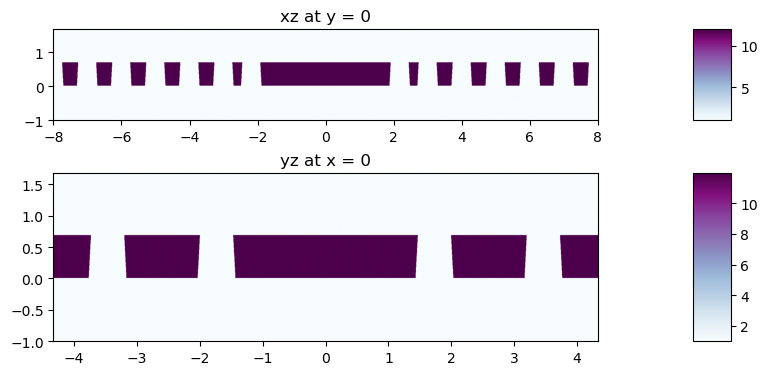

In [17]:
# Visualize the conical cavity (3 deg taper)
phc_viz = cavity_conical(3.0, n_slices=24)
legume.viz.structure(phc_viz, xz=True, yz=True, xy=False, figsize=8,
                     Nx=2000, Ny=2000, Nz=1000, cmap='BuPu')

## Convergence study: Q vs number of slices
Determine how many sub-layers are needed for converged results.

In [6]:
gmax = 2
truncate_g = 'tbt'
options = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
           'eig_sigma': f_lb, 'gradients': 'approx', 'compute_im': False}

# Convergence test at 3 deg taper (all slices identical — Q should be stable)
n_slices_list = [2, 4, 8, 16, 24, 32]
Qs_conv = []
freqs_conv = []

print('Convergence study (taper = 3 deg):')
for ns in n_slices_list:
    phc_c = cavity_conical(3, n_slices=ns)
    gme_c = legume.GuidedModeExp(phc_c, gmax=gmax, truncate_g=truncate_g)
    gme_c.run(kpoints=np.array([[0], [0]]), **options)

    # Find L3 mode: candidates inside bandgap, pick highest Q
    all_freqs = gme_c.freqs[0, :]
    candidates = np.where((all_freqs > f_lb) & (all_freqs < f_ub))[0]
    best_Q, mind = -1, 0
    for c in candidates:
        (fim, _, _) = gme_c.compute_rad(0, [c])
        Qc = gme_c.freqs[0, c] / (2 * fim[0])
        if Qc > best_Q:
            best_Q, mind = Qc, c

    Qs_conv.append(best_Q)
    freqs_conv.append(gme_c.freqs[0, mind])
    print(f'  n_slices = {ns:2d},  Q = {best_Q:10.1f},  f = {gme_c.freqs[0, mind]:.5f}')

# Plot convergence
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(n_slices_list, Qs_conv, 'o-', lw=1.5, ms=6)
ax.set_xlabel('Number of sub-layers (n_slices)')
ax.set_ylabel('Q factor')
ax.set_title('Convergence: Q vs staircase resolution (taper = 3°)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Convergence study (taper = 3 deg):


KeyboardInterrupt: 

## Baseline: no taper (0 deg)

Modes near bandgap centre (bandgap: 0.2489 – 0.3274):
  Mode 0: f = 0.23944,  Q = 32592.5
  Mode 1: f = 0.24011,  Q = 2354.2
  Mode 2: f = 0.24064,  Q = 1301.9
  Mode 3: f = 0.24364,  Q = 14322.1
  Mode 4: f = 0.24373,  Q = 6165.9
  Mode 5: f = 0.24665,  Q = 41507.8
  Mode 6: f = 0.24741,  Q = 3056.3
  Mode 7: f = 0.24785,  Q = 17063.4
  Mode 8: f = 0.24827,  Q = 5380.8
  Mode 9: f = 0.25754,  Q = 198852.0 <-- IN BANDGAP

Baseline (0 deg taper): mode_idx = 9, f = 0.25754, Q = 198852.0


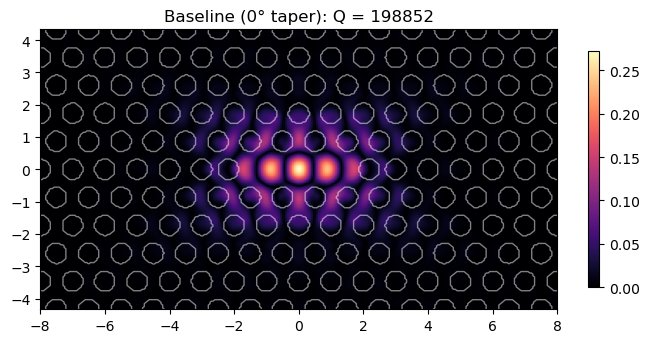

In [18]:
# Use the converged n_slices (even for 0 deg, to keep the layer count consistent)
n_slices = 24  # adjust based on convergence study above

phc_base = cavity_conical(0.0, n_slices=n_slices)
gme_base = legume.GuidedModeExp(phc_base, gmax=gmax, truncate_g=truncate_g)
gme_base.run(kpoints=np.array([[0], [0]]), **options)

# Identify L3 cavity mode: highest Q inside the bandgap
print(f'Modes near bandgap centre (bandgap: {f_lb:.4f} \u2013 {f_ub:.4f}):')
mode_idx = None
best_Q_base = -1
for i in range(gme_base.freqs.shape[1]):
    (freq_im_i, _, _) = gme_base.compute_rad(0, [i])
    Qi = gme_base.freqs[0, i] / (2 * freq_im_i[0])
    in_gap = f_lb < gme_base.freqs[0, i] < f_ub
    tag = ' <-- IN BANDGAP' if in_gap else ''
    print(f'  Mode {i}: f = {gme_base.freqs[0, i]:.5f},  Q = {Qi:.1f}{tag}')
    if in_gap and Qi > best_Q_base:
        best_Q_base = Qi
        mode_idx = i

if mode_idx is None:
    raise RuntimeError('No mode found inside the bandgap')

(freq_im, _, _) = gme_base.compute_rad(0, [mode_idx])
Q_base = gme_base.freqs[0, mode_idx] / (2 * freq_im[0])
f_base = gme_base.freqs[0, mode_idx]
print(f'\nBaseline (0 deg taper): mode_idx = {mode_idx}, f = {f_base:.5f}, Q = {Q_base:.1f}')

ax = legume.viz.field(gme_base, 'e', 0, mode_idx, z=dslab/2,
                      component='y', val='abs', N1=300, N2=200)
plt.title(f'Baseline (0\u00b0 taper): Q = {Q_base:.0f}')
plt.show()

## Single conical run

Taper = 3.0 deg:  f = 0.25424,  Q = 47269.4
Change from baseline:  Δf = -0.00330,  ΔQ = -151582.6


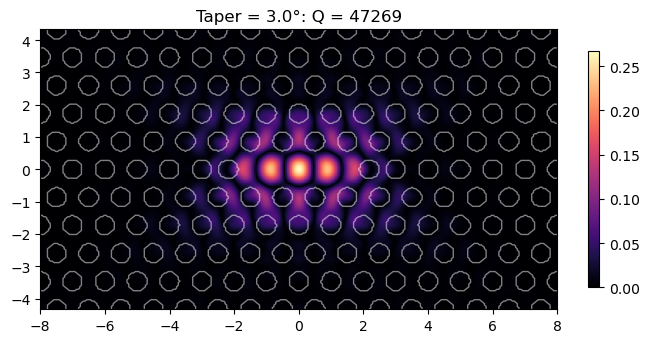

In [13]:
# Single run at 3 deg taper
taper_test = 3.0  # degrees

phc_cone = cavity_conical(taper_test, n_slices=n_slices)
gme_cone = legume.GuidedModeExp(phc_cone, gmax=gmax, truncate_g=truncate_g)
gme_cone.run(kpoints=np.array([[0], [0]]),
             gmode_inds=[0], verbose=False, numeig=10,
             eig_sigma=f_base, gradients='approx', compute_im=False)

# Find L3 mode: highest Q inside the bandgap
all_freqs = gme_cone.freqs[0, :]
candidates = np.where((all_freqs > f_lb) & (all_freqs < f_ub))[0]
best_Q, mind = -1, 0
for c in candidates:
    (fim, _, _) = gme_cone.compute_rad(0, [c])
    Qc = gme_cone.freqs[0, c] / (2 * fim[0])
    if Qc > best_Q:
        best_Q, mind = Qc, c

Q_cone = best_Q
f_cone = gme_cone.freqs[0, mind]

print(f'Taper = {taper_test} deg:  f = {f_cone:.5f},  Q = {Q_cone:.1f}')
print(f'Change from baseline:  \u0394f = {f_cone - f_base:.5f},  \u0394Q = {Q_cone - Q_base:.1f}')

ax = legume.viz.field(gme_cone, 'e', 0, mind, z=dslab/2,
                      component='y', val='abs', N1=300, N2=200)
plt.title(f'Taper = {taper_test}\u00b0: Q = {Q_cone:.0f}')
plt.show()

## Q factor vs taper angle

In [9]:
# Sweep taper angle from 0 to 5 degrees
taper_angles = np.linspace(0, 5, 21)  # 0.25 deg steps
Qs_sweep = []
freqs_sweep = []

options_sweep = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
                 'gradients': 'approx', 'compute_im': False}

f_prev = f_base  # seed tracking

print('Sweeping taper angle:')
for angle in taper_angles:
    phc_s = cavity_conical(angle, n_slices=n_slices)
    gme_s = legume.GuidedModeExp(phc_s, gmax=gmax, truncate_g=truncate_g)
    gme_s.run(kpoints=np.array([[0], [0]]), eig_sigma=f_prev, **options_sweep)

    # Find L3 mode: highest Q inside the bandgap
    all_freqs = gme_s.freqs[0, :]
    candidates = np.where((all_freqs > f_lb) & (all_freqs < f_ub))[0]
    best_Q, mind = -1, 0
    for c in candidates:
        (fim, _, _) = gme_s.compute_rad(0, [c])
        Qc = gme_s.freqs[0, c] / (2 * fim[0])
        if Qc > best_Q:
            best_Q, mind = Qc, c

    f_s = gme_s.freqs[0, mind]
    f_prev = f_s

    Qs_sweep.append(best_Q)
    freqs_sweep.append(f_s)

    r_bot = ra - dslab * np.tan(np.radians(angle))
    print(f'  angle = {angle:5.2f} deg,  r_bot = {r_bot*a_nm:5.1f} nm,  '
          f'Q = {best_Q:10.1f},  f = {f_s:.5f}  (mode {mind})')

print('Sweep complete.')

if SAVE_DATA:
    save_sweep('taper_angle', {
        'taper_angles': taper_angles,
        'Qs': np.array(Qs_sweep),
        'freqs': np.array(freqs_sweep),
    }, n_slices=n_slices)

Sweeping taper angle:
  angle =  0.00 deg,  r_bot =  75.0 nm,  Q =   198852.0,  f = 0.25754  (mode 8)
  angle =  0.25 deg,  r_bot =  74.3 nm,  Q =   197387.0,  f = 0.25723  (mode 8)
  angle =  0.50 deg,  r_bot =  73.5 nm,  Q =   188616.4,  f = 0.25693  (mode 8)
  angle =  0.75 deg,  r_bot =  72.8 nm,  Q =   174147.8,  f = 0.25663  (mode 8)
  angle =  1.00 deg,  r_bot =  72.0 nm,  Q =   156339.3,  f = 0.25635  (mode 8)
  angle =  1.25 deg,  r_bot =  71.3 nm,  Q =   137457.2,  f = 0.25606  (mode 8)
  angle =  1.50 deg,  r_bot =  70.5 nm,  Q =   119168.1,  f = 0.25579  (mode 8)
  angle =  1.75 deg,  r_bot =  69.8 nm,  Q =   102441.4,  f = 0.25552  (mode 8)
  angle =  2.00 deg,  r_bot =  69.1 nm,  Q =    87689.5,  f = 0.25525  (mode 8)
  angle =  2.25 deg,  r_bot =  68.3 nm,  Q =    74967.3,  f = 0.25499  (mode 8)
  angle =  2.50 deg,  r_bot =  67.6 nm,  Q =    64138.5,  f = 0.25474  (mode 8)
  angle =  2.75 deg,  r_bot =  66.8 nm,  Q =    54984.9,  f = 0.25449  (mode 8)
  angle =  3.00 de

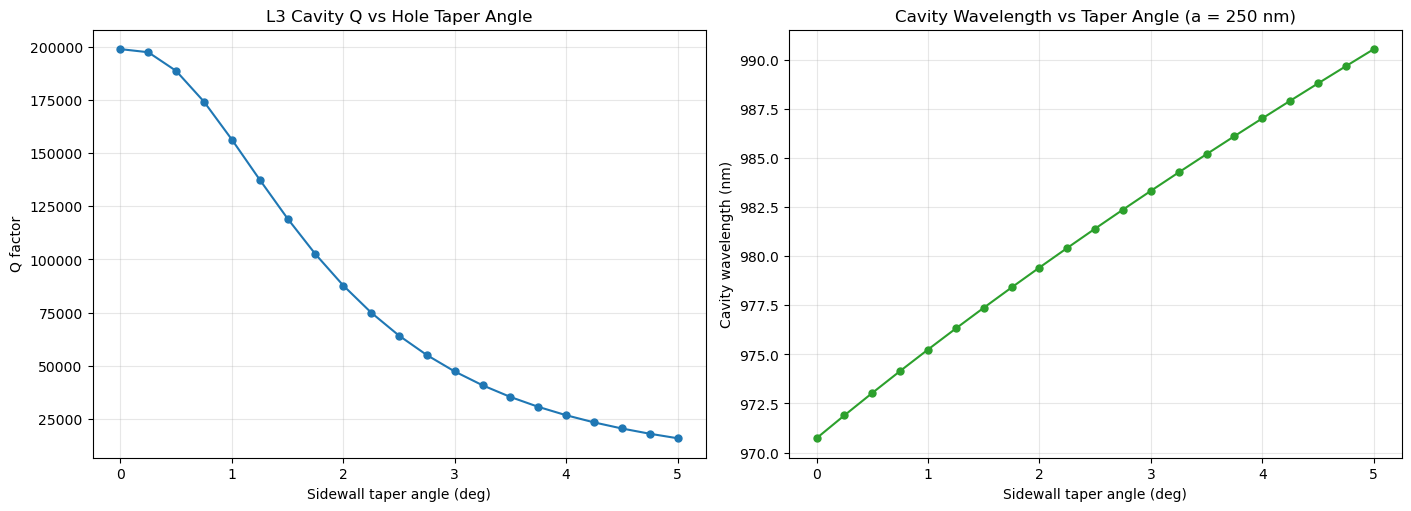

 angle (deg)  r_bot (nm)           Q    f (norm)   lambda (nm)
---------------------------------------------------------------------------
        0.00        75.0    198852.0     0.25754         970.7
        0.25        74.3    197387.0     0.25723         971.9
        0.50        73.5    188616.4     0.25693         973.0
        0.75        72.8    174147.8     0.25663         974.2
        1.00        72.0    156339.3     0.25635         975.2
        1.25        71.3    137457.2     0.25606         976.3
        1.50        70.5    119168.1     0.25579         977.4
        1.75        69.8    102441.4     0.25552         978.4
        2.00        69.1     87689.5     0.25525         979.4
        2.25        68.3     74967.3     0.25499         980.4
        2.50        67.6     64138.5     0.25474         981.4
        2.75        66.8     54984.9     0.25449         982.4
        3.00        66.1     47269.4     0.25424         983.3
        3.25        65.3     40767.4     0

In [10]:
# ── Plot sweep results ──────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# Q vs taper angle
ax1.plot(taper_angles, Qs_sweep, 'o-', lw=1.5, ms=5)
ax1.set_xlabel('Sidewall taper angle (deg)')
ax1.set_ylabel('Q factor')
ax1.set_title('L3 Cavity Q vs Hole Taper Angle')
ax1.grid(True, alpha=0.3)

# Wavelength vs taper angle
lambdas_nm = [a_nm / f for f in freqs_sweep]
ax2.plot(taper_angles, lambdas_nm, 'o-', lw=1.5, ms=5, color='tab:green')
ax2.set_xlabel('Sidewall taper angle (deg)')
ax2.set_ylabel('Cavity wavelength (nm)')
ax2.set_title(f'Cavity Wavelength vs Taper Angle (a = {a_nm} nm)')
ax2.grid(True, alpha=0.3)

plt.show()

# ── Summary table ──────────────────────────────────────────────────────────
print('=' * 75)
print(f'{"angle (deg)":>12}  {"r_bot (nm)":>10}  {"Q":>10}  {"f (norm)":>10}  {"lambda (nm)":>12}')
print('-' * 75)
for ang, q, f, lam in zip(taper_angles, Qs_sweep, freqs_sweep, lambdas_nm):
    r_bot = ra - dslab * np.tan(np.radians(ang))
    print(f'{ang:>12.2f}  {r_bot*a_nm:>10.1f}  {q:>10.1f}  {f:>10.5f}  {lam:>12.1f}')
print('=' * 75)

## Combined sweep: Q vs taper angle for different hole radii

In [19]:
# Combined sweep: taper angle for each hole radius
r_nm_list = [73, 74, 75, 76, 77]  # nm
taper_angles_r = np.linspace(0, 5, 11)  # deg
results_r = {}  # {r_nm: {'Qs': [...], 'freqs': [...]}}

options_sweep2 = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
                  'gradients': 'approx', 'compute_im': False}

for r_nm in r_nm_list:
    Qs, freqs = [], []
    f_prev = f_base  # re-seed for each radius

    print(f'\n--- r = {r_nm} nm ---')
    for angle in taper_angles_r:
        phc_s = cavity_conical(angle, n_slices=n_slices, r_nm=r_nm)
        gme_s = legume.GuidedModeExp(phc_s, gmax=gmax, truncate_g=truncate_g)
        gme_s.run(kpoints=np.array([[0], [0]]), eig_sigma=f_prev, **options_sweep2)

        # Find L3 mode: highest Q inside the bandgap
        all_freqs = gme_s.freqs[0, :]
        candidates = np.where((all_freqs > f_lb) & (all_freqs < f_ub))[0]
        best_Q, mind = -1, 0
        for c in candidates:
            (fim, _, _) = gme_s.compute_rad(0, [c])
            Qc = gme_s.freqs[0, c] / (2 * fim[0])
            if Qc > best_Q:
                best_Q, mind = Qc, c

        f_s = gme_s.freqs[0, mind]
        f_prev = f_s
        Qs.append(best_Q)
        freqs.append(f_s)
        print(f'  angle = {angle:5.2f} deg,  Q = {best_Q:10.1f},  f = {f_s:.5f}  (mode {mind})')

    results_r[r_nm] = {'Qs': Qs, 'freqs': freqs}

print('\nCombined sweep complete.')

if SAVE_DATA:
    arrays = {'taper_angles': taper_angles_r, 'r_nm_list': np.array(r_nm_list)}
    for r_nm in r_nm_list:
        arrays[f'Qs_r{r_nm}'] = np.array(results_r[r_nm]['Qs'])
        arrays[f'freqs_r{r_nm}'] = np.array(results_r[r_nm]['freqs'])
    save_sweep('radius_taper', arrays, n_slices=n_slices, r_nm_list=r_nm_list)


--- r = 73 nm ---
  angle =  0.00 deg,  Q =   196090.6,  f = 0.25588  (mode 7)
  angle =  0.50 deg,  Q =   176890.3,  f = 0.25529  (mode 8)
  angle =  1.00 deg,  Q =   140774.6,  f = 0.25473  (mode 8)
  angle =  1.50 deg,  Q =   104156.8,  f = 0.25419  (mode 8)
  angle =  2.00 deg,  Q =    74953.6,  f = 0.25366  (mode 8)
  angle =  2.50 deg,  Q =    53842.8,  f = 0.25316  (mode 7)
  angle =  3.00 deg,  Q =    39067.7,  f = 0.25267  (mode 7)
  angle =  3.50 deg,  Q =    28755.0,  f = 0.25219  (mode 7)
  angle =  4.00 deg,  Q =    21492.0,  f = 0.25173  (mode 7)
  angle =  4.50 deg,  Q =    16327.5,  f = 0.25128  (mode 7)
  angle =  5.00 deg,  Q =    12686.8,  f = 0.25084  (mode 7)

--- r = 74 nm ---
  angle =  0.00 deg,  Q =   200981.8,  f = 0.25670  (mode 8)
  angle =  0.50 deg,  Q =   185007.2,  f = 0.25610  (mode 8)
  angle =  1.00 deg,  Q =   149612.6,  f = 0.25553  (mode 8)
  angle =  1.50 deg,  Q =   112046.0,  f = 0.25498  (mode 8)
  angle =  2.00 deg,  Q =    81414.5,  f = 0.25

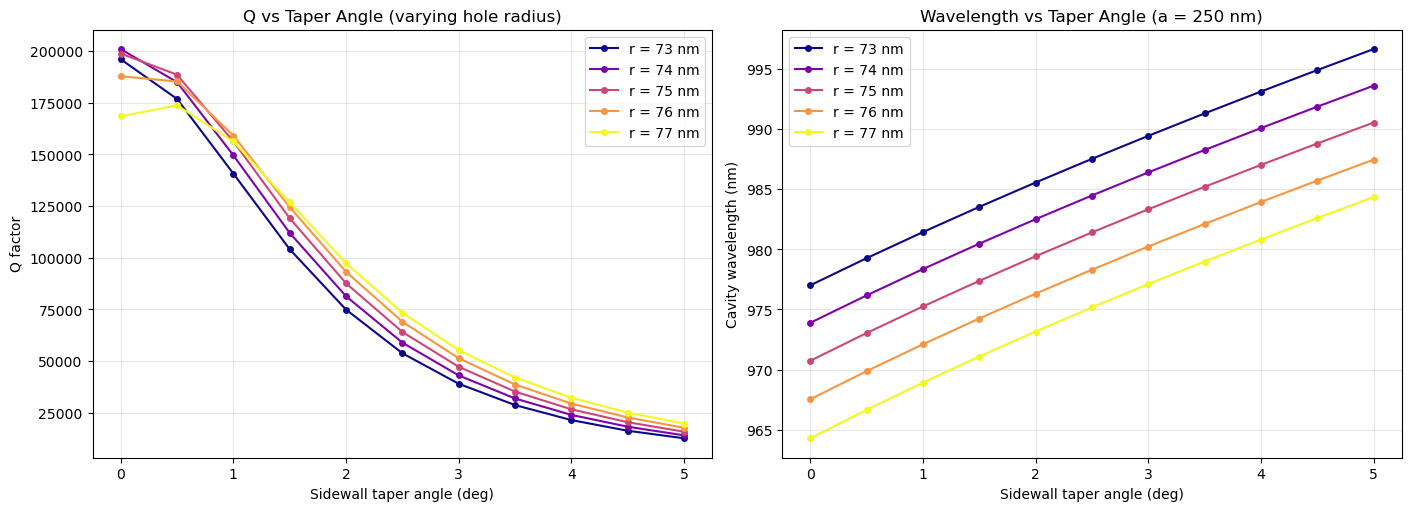

In [20]:
# ── Plot combined sweep results ────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

cmap = plt.cm.plasma
colors = [cmap(i / (len(r_nm_list) - 1)) for i in range(len(r_nm_list))]

for i, r_nm in enumerate(r_nm_list):
    label = f'r = {r_nm} nm'
    ax1.plot(taper_angles_r, results_r[r_nm]['Qs'], 'o-', ms=4, lw=1.5,
             label=label, color=colors[i])
    lambdas = [a_nm / f for f in results_r[r_nm]['freqs']]
    ax2.plot(taper_angles_r, lambdas, 'o-', ms=4, lw=1.5,
             label=label, color=colors[i])

ax1.set_xlabel('Sidewall taper angle (deg)')
ax1.set_ylabel('Q factor')
ax1.set_title('Q vs Taper Angle (varying hole radius)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Sidewall taper angle (deg)')
ax2.set_ylabel('Cavity wavelength (nm)')
ax2.set_title(f'Wavelength vs Taper Angle (a = {a_nm} nm)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.show()